# 02 Exploratory Data Analysis
Create descriptive statistics and distributions for pH, TDS, and water temperature only.

In [4]:

from pathlib import Path
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent
os.chdir(PROJECT_ROOT)

print("Working directory:", Path.cwd())


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data_preprocessing import load_data

df = load_data("data/processed/water_quality_clean.csv")

df.head()


Working directory: /Users/jakobsmacncheese/Desktop/ISU/VRO-Project
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118286 entries, 0 to 118285
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            118286 non-null  int64         
 1   created_date  118286 non-null  datetime64[ns]
 2   water_pH      118286 non-null  float64       
 3   TDS           118286 non-null  int64         
 4   water_temp    118286 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 4.5 MB
None


,id,created_date,water_pH,TDS,water_temp
0,181775,2023-01-26 11:24:00,7.60,250,24.00
1,181777,2023-01-26 11:33:00,7.60,247,24.06
2,181778,2023-01-26 12:02:00,7.60,249,24.19
3,181780,2023-01-26 12:05:00,6.92,247,24.19
4,181782,2023-01-26 12:10:00,7.30,245,24.25


In [5]:
from src.visualization import plot_time_series

plot_time_series(
    df,
    column="water_pH",
    path="results/figures/time_series_water_pH.png",
)




In [6]:
plot_time_series(
    df,
    column="TDS",
    path="results/figures/time_series_TDS.png",
)

In [7]:
plot_time_series(
    df,
    column="water_temp",
    path="results/figures/time_series_water_temp.png",
)

In [8]:
from src.visualization import plot_distributions

plot_distributions(
    df,
    directory="results/figures",
)

In [9]:
from src.visualization import plot_correlation_heatmap

plot_correlation_heatmap(
    df,
    path="results/figures/correlation_heatmap.png",
)

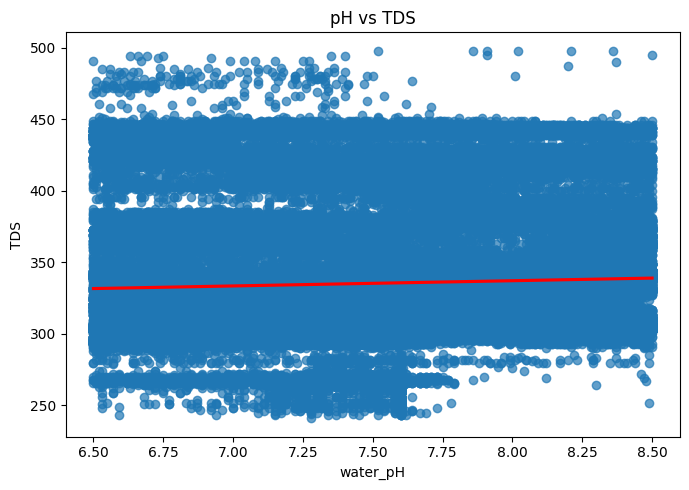

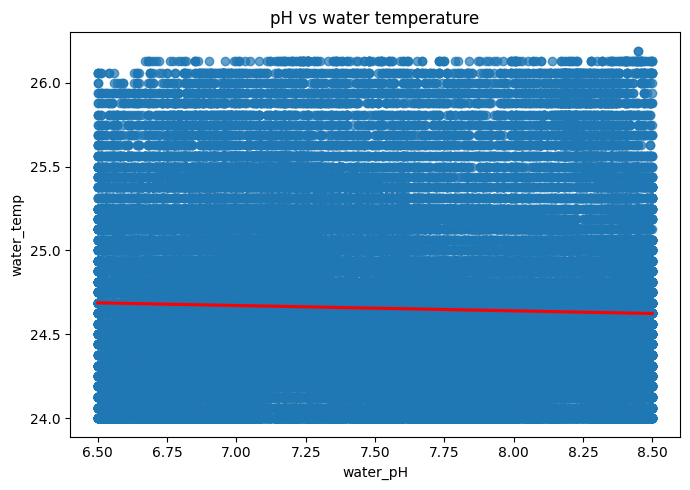

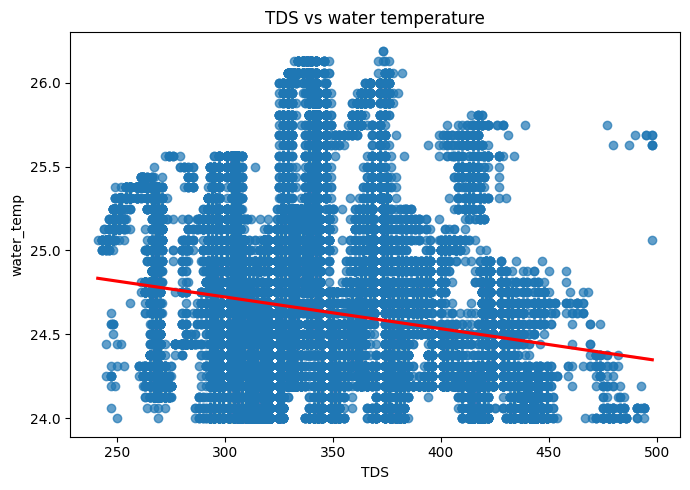

In [10]:
pairs = [
    ("water_pH", "TDS", "pH vs TDS"),
    ("water_pH", "water_temp", "pH vs water temperature"),
    ("TDS", "water_temp", "TDS vs water temperature"),
]

for x_column, y_column, title in pairs:
    figure, axis = plt.subplots(figsize=(7, 5))

    sns.regplot(
        data=df,
        x=x_column,
        y=y_column,
        scatter_kws={"alpha": 0.7},
        line_kws={"color": "red"},
        ax=axis,
    )

    axis.set_title(title)
    axis.set_xlabel(x_column)
    axis.set_ylabel(y_column)

    output_name = f"scatter_{x_column}_vs_{y_column}.png"
    figure.tight_layout()
    figure.savefig(
        Path("results/figures") / output_name,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(figure)

In [14]:
from src.exploratory_analysis import descriptive_statistics

summary = descriptive_statistics(df)
summary

summary.to_csv("results/tables/descriptive_statistics.csv")


from src.visualization import (
    plot_correlation_heatmap,
    plot_distributions,
    plot_time_series,
)

for column in ["water_pH", "TDS", "water_temp"]:
    plot_time_series(
        df,
        column=column,
        path=f"results/figures/time_series_{column}.png",
    )

plot_distributions(df, "results/figures")

plot_correlation_heatmap(
    df,
    "results/figures/correlation_heatmap.png",
)